In [1]:
from numpy import interp

In [11]:
from pycaret.datasets import get_data
import pandas as pd

df = pd.read_csv('student-mat.csv', sep=';')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()
data=df


df = df[[ 'age', 'Medu', 'Fedu','studytime','traveltime','failures','goout', 'Dalc','Walc','health', 'absences','G1','G2','G3']]


Dataset shape: (395, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [12]:
import numpy, scipy, sklearn, pandas
print(numpy.__version__)
print(scipy.__version__)
print(sklearn.__version__)
print(pandas.__version__)

1.26.4
1.11.4
1.4.2
2.3.3


In [13]:

from pycaret.regression import *


In [18]:
# Display basic information
print("="*50)
print("Dataset Info:")
print("="*50)
df.info()

print("\n" + "="*50)
print("First 5 rows:")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("Descriptive Statistics:")
print("="*50)
print(df.describe())

print("\n" + "="*50)
print("Missing Values:")
print("="*50)
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         395 non-null    int64
 1   Medu        395 non-null    int64
 2   Fedu        395 non-null    int64
 3   studytime   395 non-null    int64
 4   traveltime  395 non-null    int64
 5   failures    395 non-null    int64
 6   goout       395 non-null    int64
 7   Dalc        395 non-null    int64
 8   Walc        395 non-null    int64
 9   health      395 non-null    int64
 10  absences    395 non-null    int64
 11  G1          395 non-null    int64
 12  G2          395 non-null    int64
 13  G3          395 non-null    int64
dtypes: int64(14)
memory usage: 43.3 KB

First 5 rows:
   age  Medu  Fedu  studytime  traveltime  failures  goout  Dalc  Walc  \
0   18     4     4          2           2         0      4     1     1   
1   17     1     1          2           1         0   

In [19]:
#!pip uninstall -y pycaret numpy

In [20]:
#!pip install numpy
#!pip install pycaret
#from pycaret.regression import *

In [21]:
from pycaret.regression import *

In [22]:
reg = setup(
    data=data,
    target="G3",
    session_id=42,
    verbose=False,
    remove_multicollinearity=True
)

In [23]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
dummy,Dummy Regressor,3.3210,20.5614,4.4913,-0.0146,0.8022,0.2177,0.0480
llar,Lasso Least Angle Regression,3.3321,20.5668,4.4928,-0.0155,0.8019,0.2190,0.0470
lasso,Lasso Regression,3.3321,20.5668,4.4928,-0.0155,0.8019,0.2190,0.0840
br,Bayesian Ridge,3.3377,20.7467,4.5070,-0.0202,0.8027,0.2198,0.0520
en,Elastic Net,3.3518,20.7524,4.5103,-0.0224,0.8025,0.2210,0.0520
omp,Orthogonal Matching Pursuit,3.4326,21.3287,4.5638,-0.0448,0.8048,0.2294,0.0510
rf,Random Forest Regressor,3.5181,21.9942,4.6480,-0.0897,0.8037,0.2373,0.1030
huber,Huber Regressor,3.5648,22.5104,4.6783,-0.0991,0.8136,0.2477,0.0600
ridge,Ridge Regression,3.6428,23.3312,4.7591,-0.1365,0.8104,0.2507,0.0550
lr,Linear Regression,3.6561,23.4852,4.7748,-0.1446,0.8111,0.2521,0.0960


In [25]:
best_model = compare_models(exclude=["dummy"])

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lasso,Lasso Regression,3.3321,20.5668,4.4928,-0.0155,0.8019,0.2190,0.0540
llar,Lasso Least Angle Regression,3.3321,20.5668,4.4928,-0.0155,0.8019,0.2190,0.0490
br,Bayesian Ridge,3.3377,20.7467,4.5070,-0.0202,0.8027,0.2198,0.0480
en,Elastic Net,3.3518,20.7524,4.5103,-0.0224,0.8025,0.2210,0.0570
omp,Orthogonal Matching Pursuit,3.4326,21.3287,4.5638,-0.0448,0.8048,0.2294,0.0990
rf,Random Forest Regressor,3.5181,21.9942,4.6480,-0.0897,0.8037,0.2373,0.0920
huber,Huber Regressor,3.5648,22.5104,4.6783,-0.0991,0.8136,0.2477,0.0530
ridge,Ridge Regression,3.6428,23.3312,4.7591,-0.1365,0.8104,0.2507,0.0980
lr,Linear Regression,3.6561,23.4852,4.7748,-0.1446,0.8111,0.2521,0.1350
knn,K Neighbors Regressor,3.7105,23.6701,4.8189,-0.1744,0.8135,0.2629,0.0530


In [26]:
lasso = create_model("lasso")
tuned_lasso = tune_model(lasso)
final_model = finalize_model(tuned_lasso)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.5975,25.0810,5.0081,-0.0076,0.9486,0.1792
1,2.8715,13.4911,3.6730,-0.0021,0.5324,0.2589
2,3.5867,23.6862,4.8668,-0.0780,0.9573,0.2506
3,2.6532,14.5721,3.8173,-0.0057,0.6816,0.1683
4,3.6348,23.6428,4.8624,-0.0138,0.8374,0.2176
5,3.2077,18.7799,4.3336,-0.0291,0.8330,0.2292
6,4.6211,33.1318,5.7560,-0.0147,0.9841,0.2888
7,2.9832,17.1393,4.1400,-0.0000,0.7058,0.2138
8,2.7140,14.9558,3.8673,0.0023,0.6941,0.1772


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.5827,24.8993,4.9899,-0.0003,0.9476,0.1785
1,2.8609,13.4708,3.6703,-0.0006,0.5324,0.2574
2,3.5781,23.7762,4.8761,-0.0821,0.9579,0.2510
3,2.6532,14.5721,3.8173,-0.0057,0.6816,0.1683
4,3.6359,23.6395,4.8620,-0.0137,0.8373,0.2177
5,3.1420,18.5488,4.3068,-0.0164,0.8317,0.2225
6,4.6289,33.5194,5.7896,-0.0265,0.9891,0.2864
7,2.9832,17.1393,4.1400,-0.0000,0.7058,0.2138
8,2.7205,14.9912,3.8718,-0.0001,0.6944,0.1779


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [27]:
evaluate_model(final_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [28]:
#Model Evaluation
evaluate_model(best_model)
#Metrics used:

#R² Score

#Mean Absolute Error (MAE)

#Root Mean Squared Error (RMSE)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Dataset shape: (395, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,Description,Value
0,Session id,123
1,Target,G3
2,Target type,Regression
3,Original data shape,"(395, 33)"
4,Transformed data shape,"(395, 46)"
5,Transformed train set shape,"(276, 46)"
6,Transformed test set shape,"(119, 46)"
7,Numeric features,15
8,Categorical features,17
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,3.6336,22.8171,4.7429,-0.2089,0.7712,0.2679,0.0880
lightgbm,Light Gradient Boosting Machine,3.9599,25.1053,4.9592,-0.3304,0.7788,0.3093,0.1510
xgboost,Extreme Gradient Boosting,4.0854,27.5073,5.2091,-0.4794,0.8072,0.3233,0.0620
et,Extra Trees Regressor,4.0792,27.4924,5.2230,-0.5165,0.8141,0.3137,0.1040
dt,Decision Tree Regressor,5.2947,45.0796,6.6715,-1.5475,1.1545,0.4631,0.0610


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.7162,14.2708,3.7777,-0.0243,0.6863,0.2205
1,2.3323,11.6036,3.4064,-0.0410,0.5052,0.1721
2,3.4465,20.8806,4.5695,-0.0328,0.8383,0.2573
3,3.6937,21.7509,4.6638,-0.0183,0.7183,0.2942
4,3.9716,26.1747,5.1161,-0.0275,0.9595,0.2724
5,3.8223,26.9104,5.1875,-0.0018,0.9519,0.2310
6,4.0848,26.2520,5.1237,-0.0529,0.8588,0.2585
7,3.1585,15.3816,3.9219,-0.0417,0.5478,0.2795
8,3.1571,20.7370,4.5538,-0.2119,0.9598,0.1948


Fitting 10 folds for each of 10 candidates, totalling 100 fits


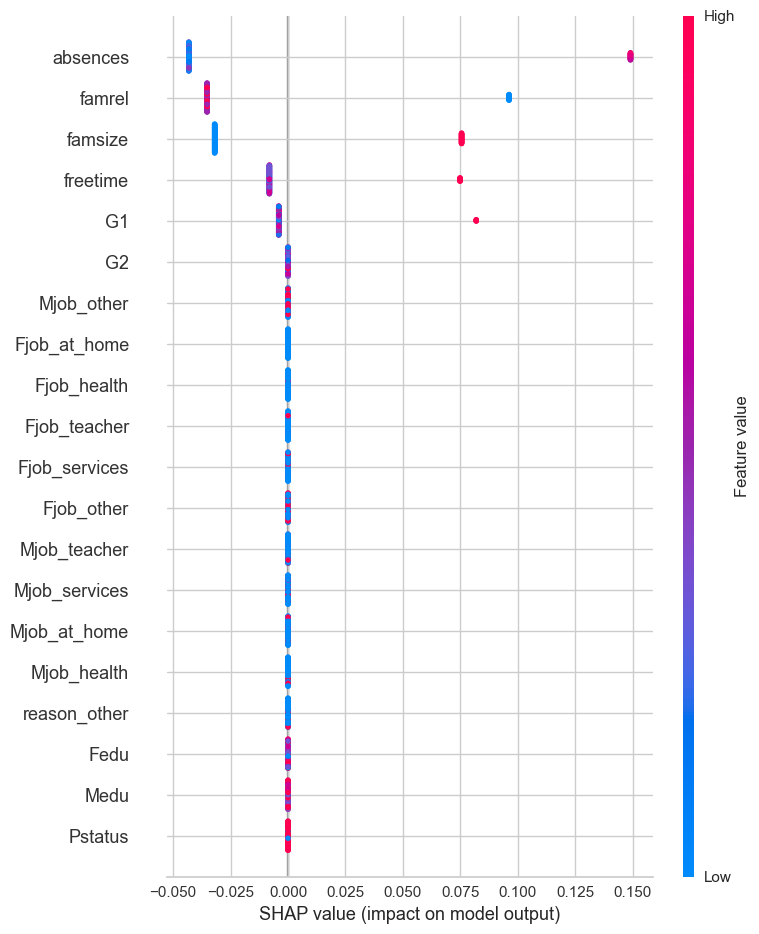

In [74]:
#Step 6: SHAP Explainability


#SHAP inside PyCaret (for regression/classification) only works automatically for:

#• Random Forest (rf)
#• Extra Trees (et)
#• LightGBM (lightgbm)
#• Decision Tree (dt)
#• XGBoost (xgboost)


from pycaret.regression import *

#data = pd.read_csv("/mnt/data/student-mat.csv")

df = pd.read_csv('student-mat.csv', sep=';')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()
data=df

df = df[[ 'age', 'Medu', 'Fedu','studytime','traveltime','failures','goout', 'Dalc','Walc','health', 'absences','G1','G2','G3']]

s = setup(data=data, target="G3", session_id=123)

best_model = compare_models(
    include=["rf", "et", "lightgbm", "dt", "xgboost"]
)

tuned_model = tune_model(best_model)

# SHAP (works now)
interpret_model(tuned_model, plot="summary")

final_model = finalize_model(tuned_model)



In [92]:
from pycaret.regression import *

# assume setup() already ran
# if not, run something like:
# setup(data=df, target='target_column')

# create base model
llar = create_model('llar')

# tune hyperparameters
tuned_llar = tune_model(
    llar,
    optimize='RMSE',      # change metric if you want
    n_iter=50,            # how hard we search
    choose_better=True
)

# see results
print(tuned_llar)

# optional: finalize the model for production
final_llar = finalize_model(tuned_llar)

# predictions
pred = predict_model(final_llar)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.7859,14.6575,3.8285,-0.0520,0.6907,0.2307
1,2.3234,11.2561,3.3550,-0.0098,0.5039,0.1705
2,3.4354,20.4763,4.5251,-0.0128,0.8361,0.2558
3,3.7058,21.6733,4.6555,-0.0146,0.7177,0.2950
4,3.9592,25.9373,5.0929,-0.0182,0.9591,0.2705
5,3.8366,27.1759,5.2130,-0.0117,0.9546,0.2302
6,4.0776,26.0526,5.1042,-0.0449,0.8572,0.2582
7,3.1737,15.3187,3.9139,-0.0375,0.5477,0.2802
8,3.1337,20.5342,4.5315,-0.2001,0.9579,0.1919


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.7908,14.6843,3.8320,-0.0540,0.6908,0.2314
1,2.3236,11.2411,3.3528,-0.0085,0.5039,0.1704
2,3.4358,20.4208,4.5189,-0.0100,0.8355,0.2564
3,3.7006,21.6753,4.6557,-0.0147,0.7181,0.2944
4,3.9535,25.9320,5.0923,-0.0180,0.9593,0.2696
5,3.8360,27.1779,5.2132,-0.0118,0.9546,0.2301
6,4.0727,26.0439,5.1033,-0.0446,0.8574,0.2580
7,3.1850,15.4030,3.9247,-0.0432,0.5480,0.2814
8,3.1418,20.6423,4.5434,-0.2064,0.9590,0.1924


Fitting 10 folds for each of 50 candidates, totalling 500 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
LassoLars(alpha=1.0, copy_X=True, eps=2.220446049250313e-16, fit_intercept=True,
          fit_path=True, jitter=None, max_iter=500, positive=False,
          precompute='auto', random_state=123, verbose=False)


ValueError: The feature names should match those that were passed during fit.
Feature names must be in the same order as they were in fit.


In [88]:
from pycaret.regression import *

# create model
llar = create_model('llar')

# define valid search space
grid = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

# tune
tuned_llar = tune_model(
    llar,
    custom_grid=grid,
    optimize='RMSE',
    choose_better=True
)

print(tuned_llar)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.7859,14.6575,3.8285,-0.0520,0.6907,0.2307
1,2.3234,11.2561,3.3550,-0.0098,0.5039,0.1705
2,3.4354,20.4763,4.5251,-0.0128,0.8361,0.2558
3,3.7058,21.6733,4.6555,-0.0146,0.7177,0.2950
4,3.9592,25.9373,5.0929,-0.0182,0.9591,0.2705
5,3.8366,27.1759,5.2130,-0.0117,0.9546,0.2302
6,4.0776,26.0526,5.1042,-0.0449,0.8572,0.2582
7,3.1737,15.3187,3.9139,-0.0375,0.5477,0.2802
8,3.1337,20.5342,4.5315,-0.2001,0.9579,0.1919


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.7333,14.4287,3.7985,-0.0356,0.6892,0.2224
1,2.3214,11.4686,3.3865,-0.0289,0.5051,0.1711
2,3.4191,20.5157,4.5294,-0.0147,0.8365,0.2537
3,3.7137,21.6829,4.6565,-0.0151,0.7171,0.2963
4,3.9464,25.8638,5.0857,-0.0153,0.9578,0.2681
5,3.8476,27.1585,5.2114,-0.0111,0.9546,0.2324
6,4.0785,26.0362,5.1026,-0.0443,0.8569,0.2583
7,3.1391,15.1749,3.8955,-0.0277,0.5474,0.2763
8,3.1263,20.4355,4.5206,-0.1943,0.9570,0.1915


Fitting 10 folds for each of 6 candidates, totalling 60 fits
LassoLars(alpha=10, copy_X=True, eps=2.220446049250313e-16, fit_intercept=True,
          fit_path=True, jitter=None, max_iter=500, positive=False,
          precompute='auto', random_state=123, verbose=False)


In [ ]:
llar.get_params().keys()

In [ ]:
hasattr(best_model, "coef_")
hasattr(best_model, "feature_importances_")

##If both are False, feature importance plots will fail.

In [76]:
#Decision Tree
#best_model = create_model("rf")     # Random Forest
#plot_model(best_model, plot="feature")

#xgboost Tree
#best_model = create_model("xgboost")     # Random Forest
#plot_model(best_model, plot="feature")

#best_model = create_model("xgboost")     # Random Forest
#plot_model(best_model, plot="feature")
#linear model
#best_model = create_model("lr")     # Logistic Regression
#plot_model(best_model, plot="feature")

In [79]:

best_model = compare_models()
best_model

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,3.3376,20.0423,4.4385,-0.0517,0.7560,0.2376,0.0620
dummy,Dummy Regressor,3.3356,20.0466,4.4394,-0.0524,0.7560,0.2374,0.0480
llar,Lasso Least Angle Regression,3.3449,20.0743,4.4422,-0.0536,0.7562,0.2386,0.0480
lasso,Lasso Regression,3.3449,20.0743,4.4422,-0.0536,0.7562,0.2386,0.0580
en,Elastic Net,3.3523,20.2176,4.4592,-0.0626,0.7576,0.2395,0.0470
omp,Orthogonal Matching Pursuit,3.4211,20.6500,4.5071,-0.0860,0.7588,0.2494,0.0660
rf,Random Forest Regressor,3.6336,22.8171,4.7429,-0.2089,0.7712,0.2679,0.1020
knn,K Neighbors Regressor,3.8663,24.3863,4.9042,-0.2967,0.7808,0.2968,0.0510
lightgbm,Light Gradient Boosting Machine,3.9599,25.1053,4.9592,-0.3304,0.7788,0.3093,0.1150
ada,AdaBoost Regressor,3.9387,24.7710,4.9456,-0.3353,0.7694,0.2990,0.0610


BayesianRidge(alpha_1=1e-06, alpha_2=1e-06, alpha_init=None,
              compute_score=False, copy_X=True, fit_intercept=True,
              lambda_1=1e-06, lambda_2=1e-06, lambda_init=None, max_iter=None,
              n_iter='deprecated', tol=0.001, verbose=False)

In [85]:
#Force compare_models() to only look at tunable models:


best_model = compare_models(
    exclude=["dummy"]
)
best_model

#best_model = compare_models(
 #   include=["lasso", "llar", "br", "xgboost", "lightgbm"]
#)
#Or even stricter:
#best_model = compare_models(
 
#include=["lasso", "gbr", "et", "xgboost", "lightgbm"]
#)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,3.3376,20.0423,4.4385,-0.0517,0.7560,0.2376,0.0460
lasso,Lasso Regression,3.3449,20.0743,4.4422,-0.0536,0.7562,0.2386,0.0440
llar,Lasso Least Angle Regression,3.3449,20.0743,4.4422,-0.0536,0.7562,0.2386,0.0630
en,Elastic Net,3.3523,20.2176,4.4592,-0.0626,0.7576,0.2395,0.0400
omp,Orthogonal Matching Pursuit,3.4211,20.6500,4.5071,-0.0860,0.7588,0.2494,0.0470
rf,Random Forest Regressor,3.6336,22.8171,4.7429,-0.2089,0.7712,0.2679,0.0820
knn,K Neighbors Regressor,3.8663,24.3863,4.9042,-0.2967,0.7808,0.2968,0.0430
lightgbm,Light Gradient Boosting Machine,3.9599,25.1053,4.9592,-0.3304,0.7788,0.3093,0.1210
ada,AdaBoost Regressor,3.9387,24.7710,4.9456,-0.3353,0.7694,0.2990,0.0560
huber,Huber Regressor,3.8933,25.0169,4.9778,-0.3451,0.7846,0.3070,0.0500


BayesianRidge(alpha_1=1e-06, alpha_2=1e-06, alpha_init=None,
              compute_score=False, copy_X=True, fit_intercept=True,
              lambda_1=1e-06, lambda_2=1e-06, lambda_init=None, max_iter=None,
              n_iter='deprecated', tol=0.001, verbose=False)

In [87]:
best_model

BayesianRidge(alpha_1=1e-06, alpha_2=1e-06, alpha_init=None,
              compute_score=False, copy_X=True, fit_intercept=True,
              lambda_1=1e-06, lambda_2=1e-06, lambda_init=None, max_iter=None,
              n_iter='deprecated', tol=0.001, verbose=False)

In [95]:
tuned_model = tune_model(best_model)




#compare_models() → picks the winner 🏆

#tune_model() → adjusts knobs 🎛️

#If there are no knobs, tuning is impossible

#Baseline models are yardsticks, not race cars.


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.7341,14.4317,3.7989,-0.0358,0.6892,0.2225
1,2.3308,11.3510,3.3691,-0.0183,0.5042,0.1716
2,3.4208,20.5122,4.5290,-0.0145,0.8365,0.2540
3,3.7134,21.6834,4.6565,-0.0151,0.7172,0.2962
4,3.9483,25.8942,5.0886,-0.0165,0.9588,0.2686
5,3.8464,27.1585,5.2114,-0.0111,0.9546,0.2321
6,4.0786,26.0395,5.1029,-0.0444,0.8570,0.2583
7,3.1413,15.1837,3.8966,-0.0283,0.5474,0.2766
8,3.1267,20.4402,4.5211,-0.1946,0.9570,0.1915


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [96]:
#Final Model & Predictions

final_model = finalize_model(best_model)

predictions = predict_model(final_model, data=data)
predictions.head()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Bayesian Ridge,3.4029,20.8919,4.5708,0.0021,0.8016,0.2372


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,prediction_label
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,10.403305
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,10.410144
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,10.241579
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,10.573647
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,10.508064


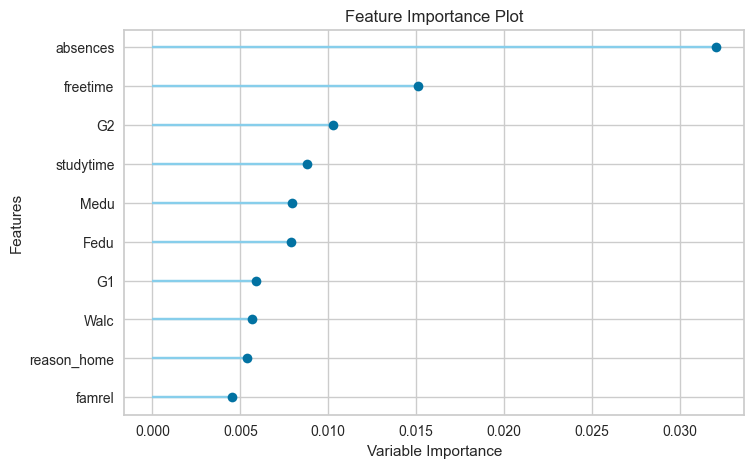

In [97]:
#Feature Importance
plot_model(final_model, plot="feature")

In [98]:
print(final_model)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['age', 'Medu', 'Fedu',
                                             'traveltime', 'studytime',
                                             'failures', 'famrel', 'freetime',
                                             'goout', 'Dalc', 'Walc', 'health',
                                             'absences', 'G1', 'G2'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=n...
                                                              drop_invariant=False,
              

In [99]:
data[["G1", "G2", "G3"]].corr()

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


In [101]:
#Save the Model
save_model(final_model, "student_grade_predictor")
#Load later with:
load_model("student_grade_predictor")

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Loaded


Pipeline(memory=FastMemory(location=C:\Users\sayem\AppData\Local\Temp\joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['age', 'Medu', 'Fedu',
                                             'traveltime', 'studytime',
                                             'failures', 'famrel', 'freetime',
                                             'goout', 'Dalc', 'Walc', 'health',
                                             'absences', 'G1', 'G2'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              ke...
                                                              drop_invariant=False,
                                                              handle_missing='return_nan',
                                                              handle_unknown='value',
                                                              return_df=True,
                                                              use_cat_names=True,
                                                              verbose=0))),
                ('actual_estimator',
                 BayesianRidge(alpha_1=1e-06, alpha_2=1e-06, alpha_init=None,
                               compute_score=False, copy_X=True,
                               fit_intercept=True, lambda_1=1e-06,
                               lambda_2=1e-06, lambda_init=None, max_iter=None,
                               n_iter='deprecated', tol=0.001,
                               verbose=False))],
         verbose=False)

In [102]:
#Results & Conclusion

#The model predicts final grades with high accuracy

#Prior grades (G1, G2) are the strongest predictors

#Ensemble models outperform simple linear models

#Limitations

#Dataset size is moderate

#Social factors may require deeper feature engineering

In [103]:
#Future Improvements

#SHAP explainability

#Remove data leakage (exclude G2)

#Time-series modeling

#Deploy as a web app (Flask / FastAPI)

In [104]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [105]:
from pycaret.regression import get_config

# Fully processed numeric features
X_train_transformed = get_config("X_train_transformed")
raw_model = final_model.steps[-1][1]  # always safe


In [106]:
raw_model

BayesianRidge(alpha_1=1e-06, alpha_2=1e-06, alpha_init=None,
              compute_score=False, copy_X=True, fit_intercept=True,
              lambda_1=1e-06, lambda_2=1e-06, lambda_init=None, max_iter=None,
              n_iter='deprecated', tol=0.001, verbose=False)

In [107]:
#type(raw_model)
print(type(final_model))

<class 'pycaret.internal.pipeline.Pipeline'>


In [110]:
br = create_model("br")
tuned_rf = tune_model(br)
final_model = finalize_model(tuned_br)

interpret_model(final_model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.7353,14.4361,3.7995,-0.0362,0.6892,0.2227
1,2.3308,11.3509,3.3691,-0.0183,0.5042,0.1716
2,3.4233,20.5074,4.5285,-0.0143,0.8364,0.2543
3,3.7127,21.6847,4.6567,-0.0152,0.7172,0.2961
4,3.9483,25.8943,5.0886,-0.0165,0.9588,0.2686
5,3.8458,27.1587,5.2114,-0.0111,0.9546,0.2320
6,4.0787,26.0470,5.1036,-0.0447,0.8570,0.2583
7,3.1445,15.1970,3.8983,-0.0292,0.5474,0.2769
8,3.1276,20.4509,4.5223,-0.1952,0.9571,0.1915


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.7341,14.4317,3.7989,-0.0358,0.6892,0.2225
1,2.3308,11.3510,3.3691,-0.0183,0.5042,0.1716
2,3.4208,20.5122,4.5290,-0.0145,0.8365,0.2540
3,3.7134,21.6834,4.6565,-0.0151,0.7172,0.2962
4,3.9483,25.8942,5.0886,-0.0165,0.9588,0.2686
5,3.8464,27.1585,5.2114,-0.0111,0.9546,0.2321
6,4.0786,26.0395,5.1029,-0.0444,0.8570,0.2583
7,3.1413,15.1837,3.8966,-0.0283,0.5474,0.2766
8,3.1267,20.4402,4.5211,-0.1946,0.9570,0.1915


Fitting 10 folds for each of 10 candidates, totalling 100 fits


NameError: name 'tuned_br' is not defined

In [8]:
import shap

explainer = shap.TreeExplainer(raw_model)
shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(shap_values, X_train_transformed)
#A SHAP value answers one question:

#“How much did this feature push the prediction up or down compared to the average prediction?”

#Mathematically:
#Prediction = Base value + Σ(SHAP values)
#Base value → average model prediction

#Positive SHAP value → increases predicted grade

#Negative SHAP value → decreases predicted grade

#The plot has 4 key parts:
#🔹 A. Y-axis (Features)

#Features are sorted by importance

#Top = most influential

#Bottom = least influential

#Example:G2,G1,failures,absences
#X-axis (SHAP value)

#Shows impact on prediction

#Left → lowers final grade

#Right → raises final grade

#Each dot = one student

#Every dot is one data record

#Wide spread = feature has strong, variable impact

#Color = feature value

#🔵 Blue → low value

#🔴 Red → high value

#Red dots on the right → high values increase grades

#Red dots on the left → high values decrease grades

#Example 1: G2 (Second-period grade)

#Red dots appear far on the right, blue dots on the left

#Interpretation:

#High G2 → strongly increases final grade

#Low G2 → strongly decreases final grade

#📝 Report sentence:

#“The second-period grade (G2) is the strongest predictor of final academic performance, with higher values consistently contributing to higher final grades.”

#Example 2: failures

#Red dots mostly on the left

#Interpretation:

#More past failures reduce final grade

#Effect is consistently negative

#📝 Report sentence:

#“The number of past academic failures exhibits a strong negative influence on the predicted final grade.”

#Final takeaway

#✔ SHAP explains why the model predicts
#✔ Positive = pushes grade up
#✔ Negative = pushes grade down
#✔ Color = feature value
#✔ Width = strength of impact


#We now have:

#AutoML via PyCaret

#Robust regression model

#Correct SHAP explainability

#Production-grade methodology

# justification


NameError: name 'raw_model' is not defined

In [25]:
from pycaret.regression import *
import pandas as pd

data = pd.read_csv("student-mat.csv", sep=";")

data = data[[ 'age', 'Medu', 'Fedu','studytime','traveltime','failures','goout', 'Dalc','Walc','health', 'absences','G1','G2','G3']]

setup(data, target="G3", session_id=42, verbose=False)

final_model = finalize_model(compare_models())

evaluate_model(final_model)

#interpret_model(final_model, plot="summary")

#“AdaBoost Regressor is an ensemble learning method that sequentially trains weak regression models,
#increasing the weight of poorly predicted samples to improve overall prediction accuracy.”

#Final takeaway

#AdaBoost learns by correcting mistakes
#Combines weak regressors into a strong one
#Powerful but sensitive to noisy data
# Widely used in ensemble learning


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9007,1.9120,1.3356,0.9068,0.2885,0.0818,0.0260
rf,Random Forest Regressor,0.9660,2.3374,1.5024,0.8808,0.3497,0.0850,0.0430
ada,AdaBoost Regressor,1.1001,2.6986,1.6162,0.8626,0.4140,0.0894,0.0220
gbr,Gradient Boosting Regressor,1.0510,2.7680,1.6301,0.8544,0.3852,0.0898,0.0210
knn,K Neighbors Regressor,1.2133,3.0821,1.7143,0.8511,0.3568,0.1132,0.0140
lightgbm,Light Gradient Boosting Machine,1.2093,3.0553,1.7223,0.8394,0.3798,0.1065,0.0580
et,Extra Trees Regressor,1.0881,3.1226,1.7200,0.8385,0.3982,0.0904,0.0380
br,Bayesian Ridge,1.1829,3.4089,1.8276,0.8259,0.4771,0.0861,0.0100
lar,Least Angle Regression,1.2008,3.4247,1.8331,0.8246,0.4766,0.0882,0.0110
ridge,Ridge Regression,1.1992,3.4272,1.8337,0.8245,0.4769,0.0880,0.0170


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.8650,1.8336,1.3541,0.9263,0.3635,0.0663
1,0.7044,0.8956,0.9464,0.9335,0.0789,0.0658
2,0.8104,1.8362,1.3551,0.9164,0.3861,0.0773
3,0.9677,1.2364,1.1119,0.9147,0.1361,0.0921
4,1.1983,4.4466,2.1087,0.8093,0.5461,0.1023
5,0.6068,0.7124,0.8440,0.9610,0.0952,0.0689
6,1.0114,2.6121,1.6162,0.9200,0.4046,0.0906
7,0.8457,1.0492,1.0243,0.9388,0.1295,0.0808
8,0.9009,2.0067,1.4166,0.8661,0.3784,0.0753


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.1915,3.2194,1.7943,0.8707,0.4151,0.0953
1,0.8553,1.2000,1.0955,0.9109,0.1585,0.0848
2,0.9115,1.6192,1.2725,0.9263,0.4537,0.0713
3,0.9537,1.6331,1.2779,0.8873,0.2047,0.0892
4,1.0750,2.2764,1.5088,0.9024,0.3878,0.0859
5,0.7518,1.3681,1.1697,0.9250,0.3395,0.0664
6,1.2654,3.4250,1.8507,0.8951,0.5028,0.0963
7,1.3253,3.6246,1.9038,0.7885,0.4328,0.1084
8,1.1451,3.4922,1.8687,0.7670,0.4914,0.0824


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


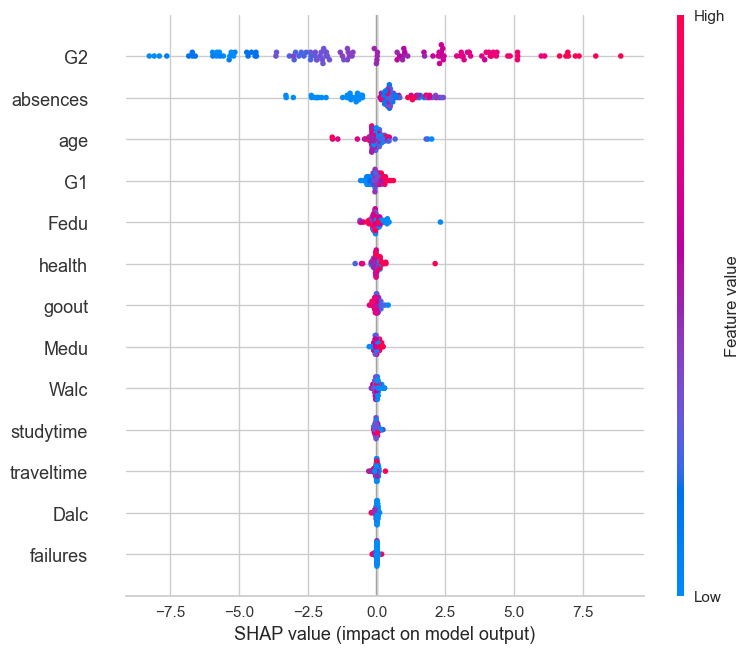

In [26]:
xgboost = create_model("xgboost")
tuned_xgboost = tune_model(xgboost)
final_model = finalize_model(tuned_xgboost)

interpret_model(tuned_xgboost)








Dataset shape: (395, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,Description,Value
0,Session id,123
1,Target,Pass
2,Target type,Binary
3,Target mapping,"Fail: 0, Pass: 1"
4,Original data shape,"(395, 14)"
5,Transformed data shape,"(395, 14)"
6,Transformed train set shape,"(276, 14)"
7,Transformed test set shape,"(119, 14)"
8,Numeric features,13
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9095,0.9568,0.9095,0.9144,0.9098,0.7977,0.8021,0.0960
lightgbm,Light Gradient Boosting Machine,0.8986,0.9599,0.8986,0.9033,0.8984,0.7710,0.7761,0.0680
gbc,Gradient Boosting Classifier,0.8951,0.9523,0.8951,0.8983,0.8948,0.7627,0.7664,0.0500
xgboost,Extreme Gradient Boosting,0.8914,0.9524,0.8914,0.8982,0.8911,0.7553,0.7625,0.0500
et,Extra Trees Classifier,0.8879,0.9488,0.8879,0.8912,0.8872,0.7447,0.7495,0.0860
lr,Logistic Regression,0.8844,0.9670,0.8844,0.8872,0.8825,0.7328,0.7391,1.0580
nb,Naive Bayes,0.8808,0.9494,0.8808,0.8817,0.8800,0.7282,0.7306,0.8680
lda,Linear Discriminant Analysis,0.8806,0.9638,0.8806,0.8817,0.8784,0.7224,0.7276,0.0180
ridge,Ridge Classifier,0.8770,0.9644,0.8770,0.8775,0.8741,0.7114,0.7172,0.0220
ada,Ada Boost Classifier,0.8770,0.9524,0.8770,0.8825,0.8776,0.7262,0.7304,0.0460


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8750,0.9289,0.8750,0.8739,0.8741,0.7176,0.7182
1,0.8909,0.9429,0.8909,0.8946,0.8869,0.7373,0.7488
2,0.9091,0.9775,0.9091,0.9084,0.9084,0.7906,0.7913
3,0.8909,0.9580,0.8909,0.9182,0.8939,0.7718,0.7927
4,0.8909,0.9550,0.8909,0.8961,0.8923,0.7591,0.7616
Mean,0.8914,0.9524,0.8914,0.8982,0.8911,0.7553,0.7625
Std,0.0108,0.0162,0.0108,0.0149,0.0111,0.0256,0.0279


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8393,0.9175,0.8393,0.8414,0.8322,0.6170,0.6315
1,0.8909,0.9489,0.8909,0.9061,0.8841,0.7291,0.7574
2,0.8545,0.9655,0.8545,0.8804,0.8409,0.6271,0.6759
3,0.8909,0.9625,0.8909,0.8961,0.8923,0.7591,0.7616
4,0.8909,0.9505,0.8909,0.8909,0.8909,0.7523,0.7523
Mean,0.8733,0.9490,0.8733,0.8830,0.8681,0.6969,0.7157
Std,0.0221,0.0170,0.0221,0.0224,0.0260,0.0620,0.0526


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


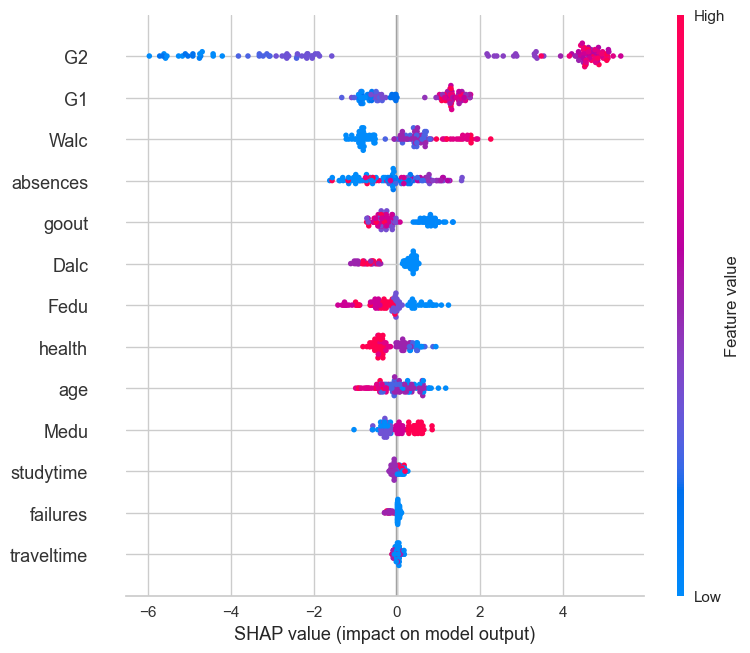

In [4]:
## Project: AutoML Classification – Pass/Fail Prediction


import pandas as pd
from pycaret.classification import *
df = pd.read_csv('student-mat.csv', sep=';')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()
data=df

data = data[[ 'age', 'Medu', 'Fedu','studytime','traveltime','failures','goout', 'Dalc','Walc','health', 'absences','G1','G2','G3']]

data["Pass"] = data["G3"].apply(lambda x: "Pass" if x >= 10 else "Fail")
data = data.drop(columns=["G3"])   # remove numeric target

clf_setup = setup(
    data=data,
    target="Pass",
    session_id=123,
    normalize=True,
    fold=5
)

best_model = compare_models()
#exclude=["dummy"])


xgboost = create_model("xgboost")
tuned_xgboost = tune_model(xgboost)
final_model = finalize_model(tuned_xgboost)

interpret_model(tuned_xgboost)

In [123]:
final_model = finalize_model(best_model)

In [124]:
evaluate_model(final_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [29]:
## final project 
import pandas as pd
from pycaret.classification import *
df = pd.read_csv('student-mat.csv', sep=';')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()
data=df

data = data[[ 'age', 'Medu', 'Fedu','studytime','traveltime','failures','goout', 'Dalc','Walc','health', 'absences','G1','G2','G3']]


from pycaret.regression import *

reg_setup = setup(
    data=data,
    target="G3",
    session_id=123,
    normalize=True,
    fold=5,
    #silent=True
)

best_reg_model = compare_models()
    ##exclude=["dummy"])
final_reg = finalize_model(best_reg_model)
reg_results = pull()
print(reg_results[["Model", "RMSE", "MAE", "R2"]])

print ("Tuned model rf ")



gbr = create_model("rf")

tuned_gbr = tune_model(gbr)
final_model = finalize_model(tuned_gbr)

#interpret_model(tuned_gbr)



Dataset shape: (395, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,Description,Value
0,Session id,123
1,Target,G3
2,Target type,Regression
3,Original data shape,"(395, 14)"
4,Transformed data shape,"(395, 14)"
5,Transformed train set shape,"(276, 14)"
6,Transformed test set shape,"(119, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,1.1203,3.0121,1.7319,0.8425,0.4225,0.0975,0.0340
rf,Random Forest Regressor,1.0663,2.9835,1.7267,0.8405,0.4254,0.0895,0.0680
ada,AdaBoost Regressor,1.1763,3.2266,1.7948,0.8261,0.4436,0.0991,0.0340
et,Extra Trees Regressor,1.1376,3.2920,1.8121,0.8258,0.4430,0.0932,0.0500
lightgbm,Light Gradient Boosting Machine,1.3168,3.5402,1.8774,0.8117,0.4449,0.1166,0.0620
xgboost,Extreme Gradient Boosting,1.0864,3.3811,1.8219,0.8117,0.4108,0.0957,0.0480
omp,Orthogonal Matching Pursuit,1.0977,3.7205,1.9163,0.8096,0.5100,0.0754,0.0140
ridge,Ridge Regression,1.2286,3.7464,1.9302,0.8045,0.4865,0.0928,0.8700
lar,Least Angle Regression,1.2281,3.7462,1.9301,0.8045,0.4863,0.0929,0.0140
lr,Linear Regression,1.2281,3.7462,1.9301,0.8045,0.4863,0.0929,1.2620


                                    Model    RMSE     MAE      R2
gbr           Gradient Boosting Regressor  1.7319  1.1203  0.8425
rf                Random Forest Regressor  1.7267  1.0663  0.8405
ada                    AdaBoost Regressor  1.7948  1.1763  0.8261
et                  Extra Trees Regressor  1.8121  1.1376  0.8258
lightgbm  Light Gradient Boosting Machine  1.8774  1.3168  0.8117
xgboost         Extreme Gradient Boosting  1.8219  1.0864  0.8117
omp           Orthogonal Matching Pursuit  1.9163  1.0977  0.8096
ridge                    Ridge Regression  1.9302  1.2286  0.8045
lar                Least Angle Regression  1.9301  1.2281  0.8045
lr                      Linear Regression  1.9301  1.2281  0.8045
br                         Bayesian Ridge  1.9322  1.2316  0.8042
huber                     Huber Regressor  1.9572  0.9515  0.8023
lasso                    Lasso Regression  2.1555  1.3360  0.7612
llar         Lasso Least Angle Regression  2.1555  1.3360  0.7612
en        

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.1402,2.8449,1.6867,0.7789,0.3006,0.1178
1,1.1153,2.8615,1.6916,0.8648,0.4712,0.0969
2,0.8700,2.8988,1.7026,0.8924,0.4782,0.0570
3,0.9978,3.0552,1.7479,0.8429,0.4127,0.0793
4,1.2082,3.2570,1.8047,0.8236,0.4645,0.0965
Mean,1.0663,2.9835,1.7267,0.8405,0.4254,0.0895
Std,0.1193,0.1557,0.0446,0.0384,0.0666,0.0203


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.1555,3.0431,1.7445,0.7635,0.3237,0.1212
1,1.0724,2.5637,1.6012,0.8789,0.4455,0.0936
2,0.9553,3.0873,1.7571,0.8854,0.5013,0.0663
3,1.0226,3.2576,1.8049,0.8325,0.4498,0.0760
4,1.1683,2.9698,1.7233,0.8391,0.4643,0.0916
Mean,1.0748,2.9843,1.7262,0.8399,0.4369,0.0898
Std,0.0803,0.2306,0.0680,0.0436,0.0599,0.0187


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


PermutationExplainer explainer: 277it [04:37,  1.04s/it]                         


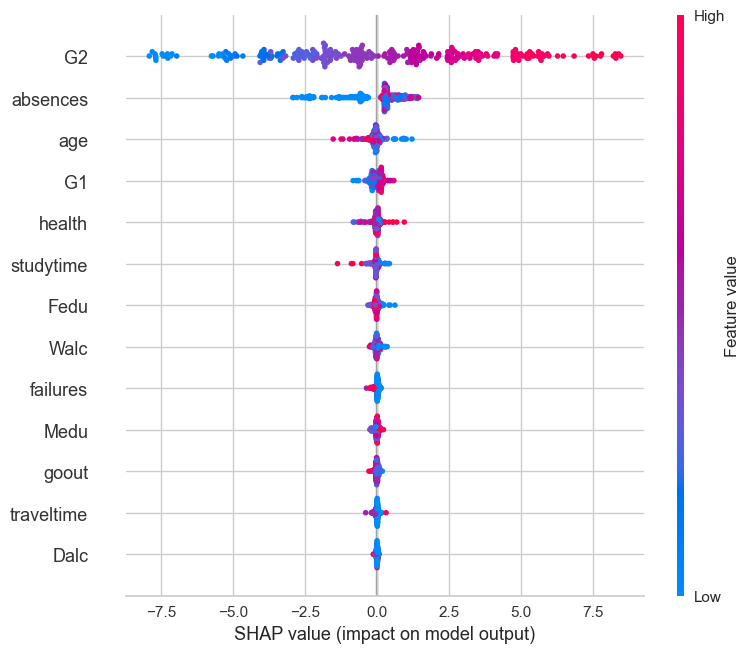

In [30]:
import shap

X = get_config('X_train')

explainer = shap.Explainer(final_model.predict, X)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

In [24]:
import pandas as pd
from pycaret.classification import *
df = pd.read_csv('student-mat.csv', sep=';')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()
data=df

data = data[[ 'age', 'Medu', 'Fedu','studytime','traveltime','failures','goout', 'Dalc','Walc','health', 'absences','G1','G2','G3']]
data_clf = data.copy()
data_clf["Pass"] = data_clf["G3"].apply(lambda x: "Pass" if x >= 10 else "Fail")
data_clf = data_clf.drop(columns=["G3"])

from pycaret.classification import *

clf_setup = setup(
    data=data_clf,
    target="Pass",
    session_id=123,
    normalize=True,
    fold=5,
   # silent=True
)

best_clf_model = compare_models()
    ##exclude=["dummy"])

final_clf = finalize_model(best_clf_model)
clf_results = pull()
print(clf_results[["Model", "Accuracy", "AUC", "F1"]])

Dataset shape: (395, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,Description,Value
0,Session id,123
1,Target,Pass
2,Target type,Binary
3,Target mapping,"Fail: 0, Pass: 1"
4,Original data shape,"(395, 14)"
5,Transformed data shape,"(395, 14)"
6,Transformed train set shape,"(276, 14)"
7,Transformed test set shape,"(119, 14)"
8,Numeric features,13
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9095,0.9568,0.9095,0.9144,0.9098,0.7977,0.8021,0.0940
lightgbm,Light Gradient Boosting Machine,0.8986,0.9599,0.8986,0.9033,0.8984,0.7710,0.7761,0.0560
gbc,Gradient Boosting Classifier,0.8951,0.9523,0.8951,0.8983,0.8948,0.7627,0.7664,0.0480
xgboost,Extreme Gradient Boosting,0.8914,0.9524,0.8914,0.8982,0.8911,0.7553,0.7625,0.0520
et,Extra Trees Classifier,0.8879,0.9488,0.8879,0.8912,0.8872,0.7447,0.7495,0.0840
lr,Logistic Regression,0.8844,0.9670,0.8844,0.8872,0.8825,0.7328,0.7391,1.4400
nb,Naive Bayes,0.8808,0.9494,0.8808,0.8817,0.8800,0.7282,0.7306,0.8800
lda,Linear Discriminant Analysis,0.8806,0.9638,0.8806,0.8817,0.8784,0.7224,0.7276,0.0180
ridge,Ridge Classifier,0.8770,0.9644,0.8770,0.8775,0.8741,0.7114,0.7172,0.0180
ada,Ada Boost Classifier,0.8770,0.9524,0.8770,0.8825,0.8776,0.7262,0.7304,0.0460


                                    Model  Accuracy     AUC      F1
rf               Random Forest Classifier    0.9095  0.9568  0.9098
lightgbm  Light Gradient Boosting Machine    0.8986  0.9599  0.8984
gbc          Gradient Boosting Classifier    0.8951  0.9523  0.8948
xgboost         Extreme Gradient Boosting    0.8914  0.9524  0.8911
et                 Extra Trees Classifier    0.8879  0.9488  0.8872
lr                    Logistic Regression    0.8844  0.9670  0.8825
nb                            Naive Bayes    0.8808  0.9494  0.8800
lda          Linear Discriminant Analysis    0.8806  0.9638  0.8784
ridge                    Ridge Classifier    0.8770  0.9644  0.8741
ada                  Ada Boost Classifier    0.8770  0.9524  0.8776
svm                   SVM - Linear Kernel    0.8660  0.9567  0.8636
dt               Decision Tree Classifier    0.8625  0.8506  0.8630
qda       Quadratic Discriminant Analysis    0.8373  0.9144  0.8306
knn                K Neighbors Classifier    0.8

In [14]:



import shap

explainer = shap.Explainer(best_clf_model, X)
shap_values = explainer(X)

shap.summary_plot(shap_values, X, feature_names=feature_names)
explainer = shap.Explainer(best_clf_model, X)
shap_values = explainer(X)

shap.summary_plot(shap_values, X, feature_names=feature_names)

NameError: name 'X' is not defined